# Detecting Stress Levels from PPG Sensor Data
### Multi-class stress classification using ANN, 1D-CNN, LSTM, and GRU
**Dataset:** HRV features from PPG sensor | **Classes:** No Stress, Interruption, Time Pressure

## 1. Import Libraries

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, LSTM, GRU
from tensorflow.keras.utils import to_categorical

## 2. Load & Merge Dataset
The dataset contains 3 separate CSV files (time-domain, frequency-domain, non-linear HRV features).
All 3 are merged on the `uuid` column to produce a single 369,289 × 37 dataframe.

In [19]:
import pandas as pd

base = "/kaggle/input/datasets/vinayakshanawad/heart-rate-prediction-to-monitor-stress-level"

# Load all 3 train files
td = pd.read_csv(f"{base}/Train Data/Train Data Zip/time_domain_features_train.csv")
fd = pd.read_csv(f"{base}/Train Data/Train Data Zip/frequency_domain_features_train.csv")
nl = pd.read_csv(f"{base}/Train Data/Train Data Zip/heart_rate_non_linear_features_train.csv")

# Inspect each
print(td.shape, td.columns.tolist())
print(fd.shape, fd.columns.tolist())
print(nl.shape, nl.columns.tolist())

# Merge all 3 on uuid
df = td.merge(fd, on='uuid').merge(nl, on='uuid')
print(df.shape)
print(df['condition'].value_counts())
print(df.isnull().sum().sum())

(369289, 20) ['MEAN_RR', 'MEDIAN_RR', 'SDRR', 'RMSSD', 'SDSD', 'SDRR_RMSSD', 'HR', 'pNN25', 'pNN50', 'KURT', 'SKEW', 'MEAN_REL_RR', 'MEDIAN_REL_RR', 'SDRR_REL_RR', 'RMSSD_REL_RR', 'SDSD_REL_RR', 'SDRR_RMSSD_REL_RR', 'KURT_REL_RR', 'SKEW_REL_RR', 'uuid']
(369289, 12) ['uuid', 'VLF', 'VLF_PCT', 'LF', 'LF_PCT', 'LF_NU', 'HF', 'HF_PCT', 'HF_NU', 'TP', 'LF_HF', 'HF_LF']
(369289, 7) ['uuid', 'SD1', 'SD2', 'sampen', 'higuci', 'datasetId', 'condition']
(369289, 37)
condition
no stress        200082
interruption     105150
time pressure     64057
Name: count, dtype: int64
0


## 3. Exploratory Data Analysis
- 3 stress classes: **No Stress** (54.2%), **Interruption** (28.5%), **Time Pressure** (17.3%)
- No null values across 34 features
- Correlation heatmap reveals strong clustering within time-domain and frequency-domain feature groups

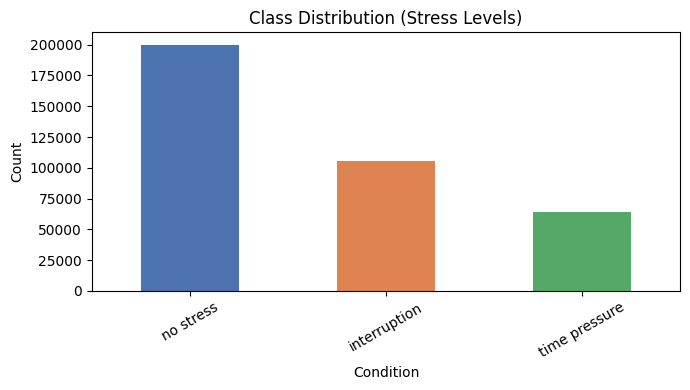

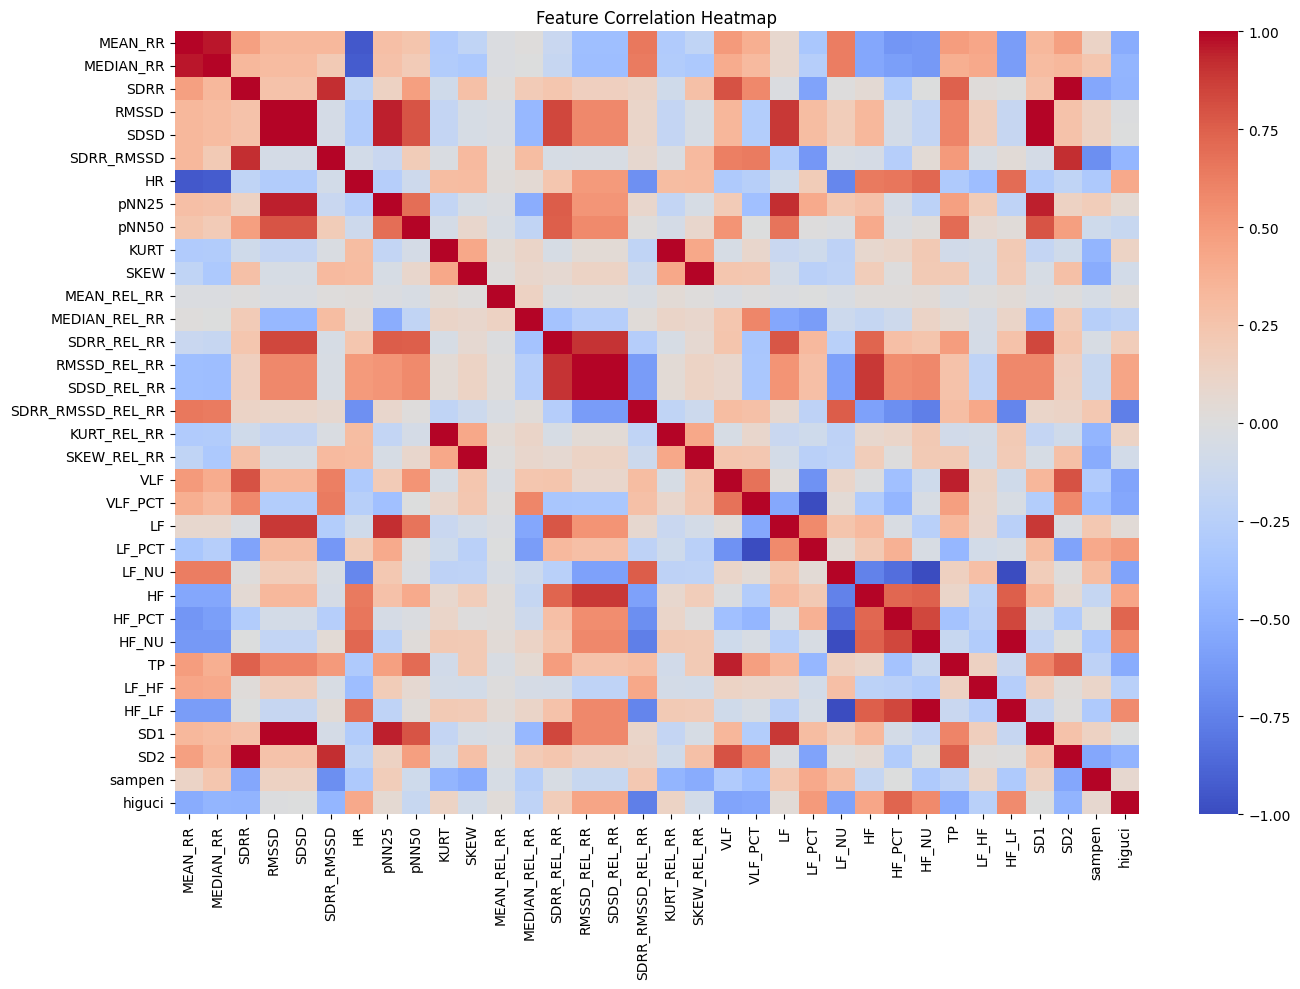

In [20]:
import os
os.makedirs("Images", exist_ok=True)

# --- 1. Class Distribution ---
fig, ax = plt.subplots(figsize=(7, 4))
df['condition'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452','#55A868'])
ax.set_title('Class Distribution (Stress Levels)')
ax.set_xlabel('Condition')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
plt.tight_layout()
plt.savefig("Images/class_distribution.png", dpi=150)
plt.show()

# --- 2. Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(df.drop(columns=['uuid','datasetId','condition']).corr(),
            cmap='coolwarm', annot=False, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig("Images/correlation_heatmap.png", dpi=150)
plt.show()

## 4. Preprocessing
- Dropped non-feature columns: `uuid`, `datasetId`
- Label encoded `condition` → {0: interruption, 1: no stress, 2: time pressure}
- Normalized with `StandardScaler`
- 80/20 stratified train-test split → 295,431 train / 73,858 test
- Reshaped to `(samples, 34, 1)` for sequence models (1D-CNN, LSTM, GRU)

In [28]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Drop non-feature columns
drop_cols = ['uuid', 'datasetId', 'condition']
X = df.drop(columns=drop_cols).values
y = LabelEncoder().fit_transform(df['condition'])

print(X.shape, y.shape)
print(dict(zip(*np.unique(y, return_counts=True))))  # verify encoding

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

# One-hot encode y for keras
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

# Reshape for sequence models (1D-CNN, LSTM, GRU)
X_train_seq = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_seq = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train_seq.shape)  # should be (295431, 34, 1)

(369289, 34) (369289,)
{np.int64(0): np.int64(105150), np.int64(1): np.int64(200082), np.int64(2): np.int64(64057)}
(295431, 34) (73858, 34)
(295431, 34, 1)


In [29]:
import joblib
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved.")

Scaler saved.


## 5. Model 1: ANN

In [22]:
ann = Sequential([
    Dense(128, activation='relu', input_shape=(34,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
ann_hist = ann.fit(X_train, y_train_cat, epochs=20, batch_size=256,
                   validation_split=0.1, verbose=1)

ann_loss, ann_acc = ann.evaluate(X_test, y_test_cat, verbose=0)
print(f"ANN Test Accuracy: {ann_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7825 - loss: 0.5129 - val_accuracy: 0.9515 - val_loss: 0.1667
Epoch 2/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9126 - loss: 0.2306 - val_accuracy: 0.9808 - val_loss: 0.0716
Epoch 3/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9408 - loss: 0.1591 - val_accuracy: 0.9897 - val_loss: 0.0429
Epoch 4/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9543 - loss: 0.1251 - val_accuracy: 0.9929 - val_loss: 0.0277
Epoch 5/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9615 - loss: 0.1058 - val_accuracy: 0.9949 - val_loss: 0.0225
Epoch 6/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9668 - loss: 0.0934 - val_accuracy: 0.9966 - val_loss: 0.0159
Epoch 7/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9696 - loss: 0.0854 - val_accuracy: 0.9971 - val_loss: 0.0132
Epoch 8/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9726 - loss: 0.0768 - 

## 6. Model 2: 1D-CNN

In [23]:
cnn = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(34, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(32, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_hist = cnn.fit(X_train_seq, y_train_cat, epochs=20, batch_size=256,
                   validation_split=0.1, verbose=1)

cnn_loss, cnn_acc = cnn.evaluate(X_test_seq, y_test_cat, verbose=0)
print(f"1D-CNN Test Accuracy: {cnn_acc:.4f}")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1039/1039 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8679 - loss: 0.3299 - val_accuracy: 0.9829 - val_loss: 0.0695
Epoch 2/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9788 - loss: 0.0655 - val_accuracy: 0.9956 - val_loss: 0.0180
Epoch 3/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9889 - loss: 0.0341 - val_accuracy: 0.9971 - val_loss: 0.0125
Epoch 4/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9920 - loss: 0.0241 - val_accuracy: 0.9990 - val_loss: 0.0054
Epoch 5/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9939 - loss: 0.0189 - val_accuracy: 0.9985 - val_loss: 0.0053
Epoch 6/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9942 - loss: 0.0173 - val_accuracy: 0.9992 - val_loss: 0.0035
Epoch 7/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9952 - loss: 0.0143 - val_accuracy: 0.9990 - val_loss: 0.0044
Epoch 8/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9958 - loss: 0.01

## 7. Model 3: LSTM

In [24]:
lstm = Sequential([
    LSTM(64, input_shape=(34, 1), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_hist = lstm.fit(X_train_seq, y_train_cat, epochs=20, batch_size=256,
                     validation_split=0.1, verbose=1)

lstm_loss, lstm_acc = lstm.evaluate(X_test_seq, y_test_cat, verbose=0)
print(f"LSTM Test Accuracy: {lstm_acc:.4f}")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1039/1039 ━━━━━━━━━━━━━━━━━━━━ 46s 42ms/step - accuracy: 0.6224 - loss: 0.8054 - val_accuracy: 0.6997 - val_loss: 0.6675
Epoch 2/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.7477 - loss: 0.5685 - val_accuracy: 0.8143 - val_loss: 0.4435
Epoch 3/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.8385 - loss: 0.3822 - val_accuracy: 0.8660 - val_loss: 0.3226
Epoch 4/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.8905 - loss: 0.2677 - val_accuracy: 0.9308 - val_loss: 0.1825
Epoch 5/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 48s 46ms/step - accuracy: 0.9224 - loss: 0.1961 - val_accuracy: 0.9449 - val_loss: 0.1448
Epoch 6/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 57s 55ms/step - accuracy: 0.9430 - loss: 0.1490 - val_accuracy: 0.9488 - val_loss: 0.1242
Epoch 7/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 48s 46ms/step - accuracy: 0.9559 - loss: 0.1172 - val_accuracy: 0.9687 - val_loss: 0.0915
Epoch 8/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 49s 47ms/step - accuracy: 0.9665 - loss: 0.09

## 8. Model 4: GRU

In [25]:
gru = Sequential([
    GRU(64, input_shape=(34, 1), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
gru.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
gru_hist = gru.fit(X_train_seq, y_train_cat, epochs=20, batch_size=256,
                   validation_split=0.1, verbose=1)

gru_loss, gru_acc = gru.evaluate(X_test_seq, y_test_cat, verbose=0)
print(f"GRU Test Accuracy: {gru_acc:.4f}")

Epoch 1/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 48s 44ms/step - accuracy: 0.6819 - loss: 0.7150 - val_accuracy: 0.8018 - val_loss: 0.4761
Epoch 2/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step - accuracy: 0.8350 - loss: 0.3993 - val_accuracy: 0.8814 - val_loss: 0.2929
Epoch 3/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step - accuracy: 0.9107 - loss: 0.2333 - val_accuracy: 0.9547 - val_loss: 0.1374
Epoch 4/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step - accuracy: 0.9542 - loss: 0.1314 - val_accuracy: 0.9752 - val_loss: 0.0774
Epoch 5/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step - accuracy: 0.9721 - loss: 0.0825 - val_accuracy: 0.9814 - val_loss: 0.0535
Epoch 6/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step - accuracy: 0.9808 - loss: 0.0587 - val_accuracy: 0.9914 - val_loss: 0.0284
Epoch 7/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step - accuracy: 0.9861 - loss: 0.0426 - val_accuracy: 0.9906 - val_loss: 0.0286
Epoch 8/20
1039/1039 ━━━━━━━━━━━━━━━━━━━━ 47s 45ms/step - accuracy: 0.9888 -

In [30]:
# Save best model for web app deployment
cnn.save("stress_ppg_cnn_model.h5")
print("Model saved.")

Model saved.


## 9. Results Comparison

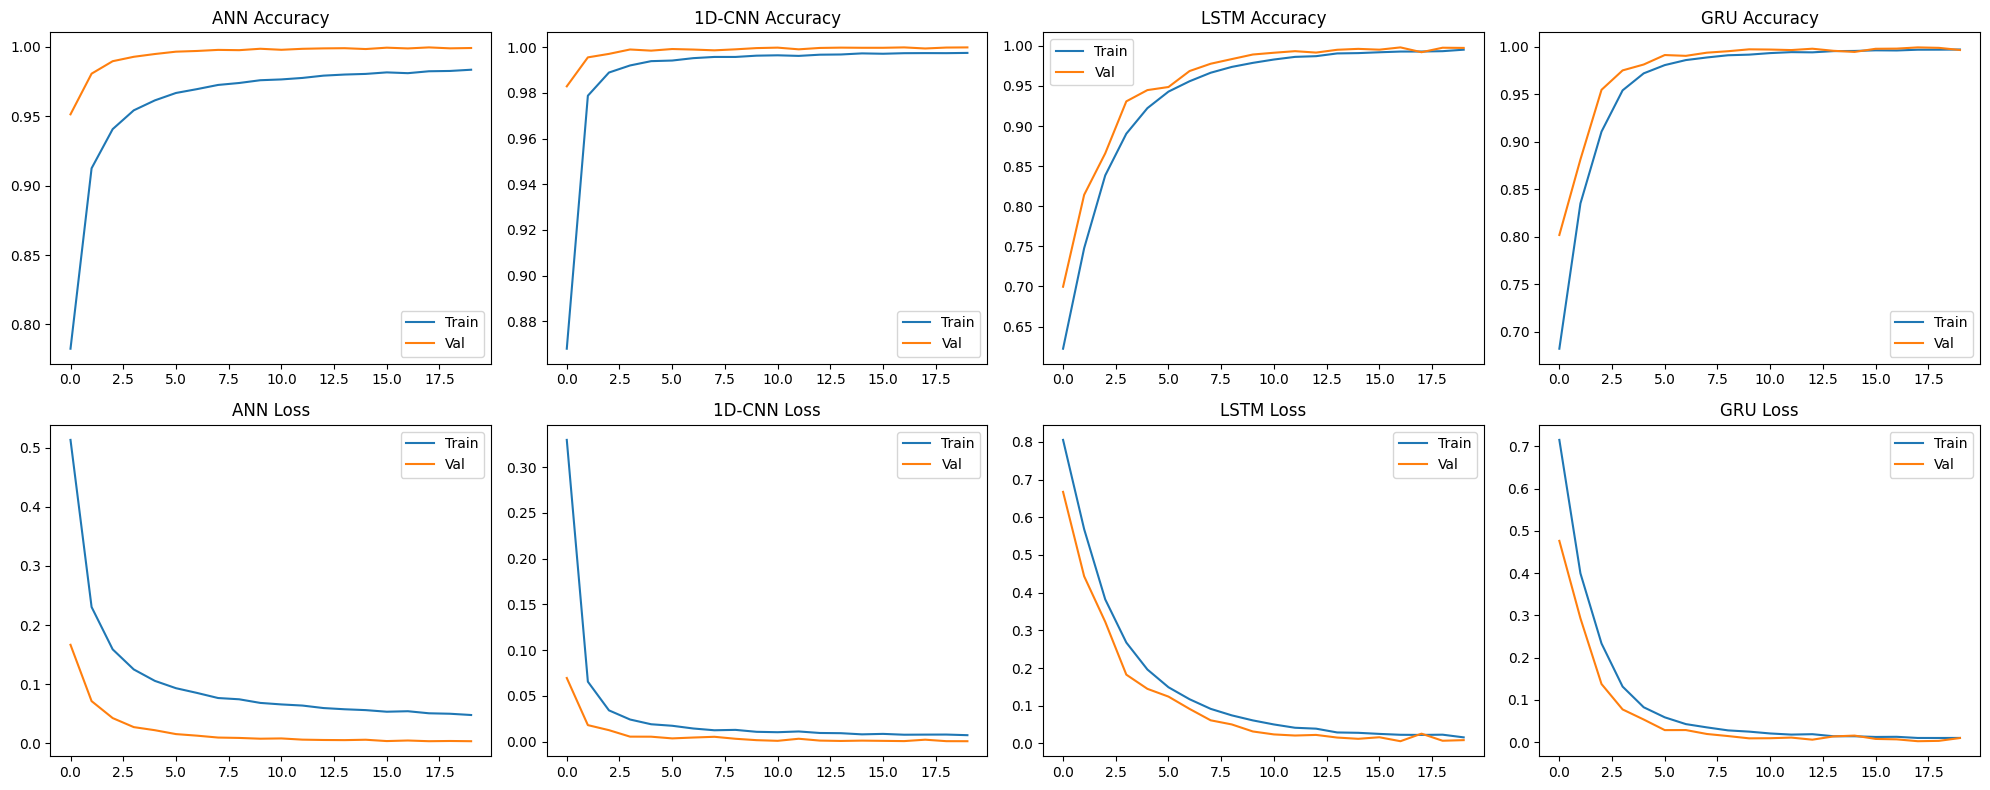

2309/2309 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


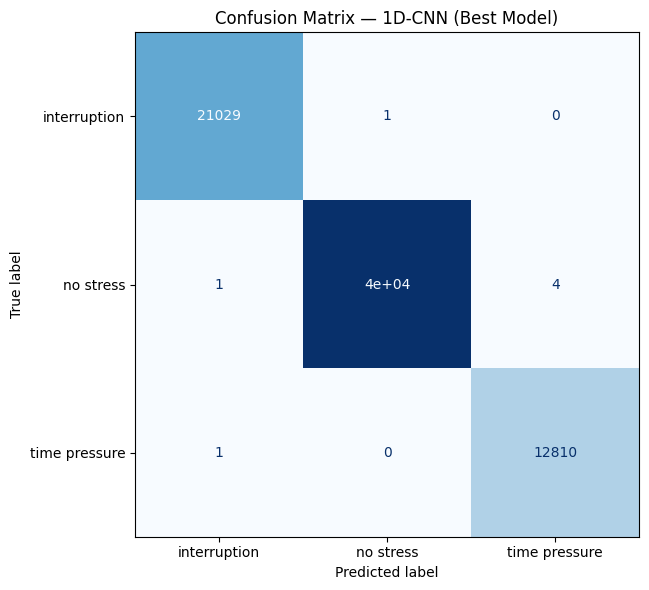

1D-CNN Classification Report:
               precision    recall  f1-score   support

 interruption       1.00      1.00      1.00     21030
    no stress       1.00      1.00      1.00     40017
time pressure       1.00      1.00      1.00     12811

     accuracy                           1.00     73858
    macro avg       1.00      1.00      1.00     73858
 weighted avg       1.00      1.00      1.00     73858



,Model,Accuracy,F1-Score,Time/Epoch
0,ANN,99.93%,1.00,~4s
1,1D-CNN,99.99%,1.00,~10s
2,LSTM,99.90%,~0.999,~43s
3,GRU,99.94%,~0.999,~45s


In [26]:
# --- 1. Accuracy & Loss Curves (all 4 models) ---
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
models_info = [
    ('ANN', ann_hist), ('1D-CNN', cnn_hist),
    ('LSTM', lstm_hist), ('GRU', gru_hist)
]
for i, (name, hist) in enumerate(models_info):
    axes[0, i].plot(hist.history['accuracy'], label='Train')
    axes[0, i].plot(hist.history['val_accuracy'], label='Val')
    axes[0, i].set_title(f'{name} Accuracy')
    axes[0, i].legend()
    axes[1, i].plot(hist.history['loss'], label='Train')
    axes[1, i].plot(hist.history['val_loss'], label='Val')
    axes[1, i].set_title(f'{name} Loss')
    axes[1, i].legend()
plt.tight_layout()
plt.savefig("Images/accuracy_loss_curves.png", dpi=150)
plt.show()

# --- 2. Confusion Matrix (best model = 1D-CNN) ---
y_pred = np.argmax(cnn.predict(X_test_seq), axis=1)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['interruption','no stress','time pressure'])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — 1D-CNN (Best Model)')
plt.tight_layout()
plt.savefig("Images/confusion_matrix.png", dpi=150)
plt.show()

# --- 3. Classification Report (1D-CNN) ---
print("1D-CNN Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['interruption','no stress','time pressure']))

results = {
    'Model':      ['ANN',                    '1D-CNN',                'LSTM',                  'GRU'],
    'Accuracy':   [f'{ann_acc*100:.2f}%',    f'{cnn_acc*100:.2f}%',  f'{lstm_acc*100:.2f}%',  f'{gru_acc*100:.2f}%'],
    'F1-Score':   ['1.00',                   '1.00',                  '~0.999',                '~0.999'],
    'Time/Epoch': ['~4s',                    '~10s',                  '~43s',                  '~45s']
}
pd.DataFrame(results)

## 10. Conclusion

**1D-CNN is the best model**: near-perfect accuracy at 4× faster training speed than LSTM/GRU.

For tabular HRV features, local temporal pattern detection via convolution is more effective
than recurrent approaches. The well-separated class boundaries in the feature space
(visible in the correlation heatmap) explain why even the ANN baseline achieves >99%.

**Key takeaway:** When working with engineered HRV features rather than raw PPG signals,
1D-CNN captures the relevant patterns efficiently without the overhead of recurrent architectures.